In [1]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.Battaglia2016 import Battaglia2016

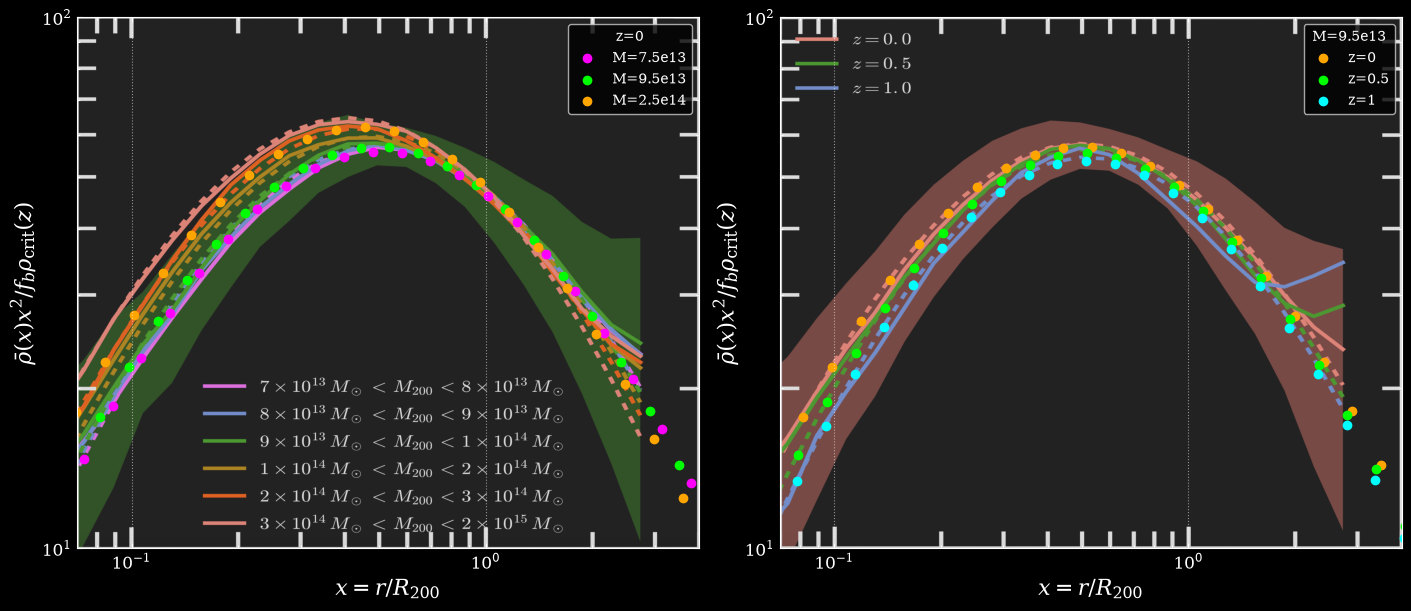

In [2]:
importlib.reload(Battaglia2016)
fig, axs = Battaglia2016.Fig5().full()

from Models import HaloModels, Profiles
importlib.reload(HaloModels); importlib.reload(Profiles)

hmod = HaloModels.pyccl_model(Profiles.Battaglia2016({'model':'AGN'}).info)

B16 = Profiles.Battaglia2016({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))

rs = np.geomspace(1e-3, 1e1, 50)
z, logMh = 0, np.log10(9.5e13)
xs = lambda z0, logMh0: rs*u.Mpc/B16.r200c(z0, logMh0)
pfunc = lambda z0, logMh0: (B16.Density(rs, z0, logMh0)()/B16.pc(z0))[:, 0, 0]*xs(z0, logMh0)**2

axs[0].scatter(xs(z, np.log10(7.5e13)), pfunc(z, np.log10(7.5e13)), c='magenta', label='M=7.5e13')
axs[0].scatter(xs(z, np.log10(9.5e13)), pfunc(z, np.log10(9.5e13)), c='lime', label='M=9.5e13')
axs[0].scatter(xs(z, np.log10(2.7e14)), pfunc(z, np.log10(2.7e14)), c='orange', label='M=2.5e14')

axs[1].scatter(xs(0, logMh), pfunc(0, logMh), c='orange', label='z=0')
axs[1].scatter(xs(0.5, logMh), pfunc(0.5, logMh), c='lime', label='z=0.5')
axs[1].scatter(xs(1, logMh), pfunc(1, logMh), c='cyan', label='z=1')

axs[0].legend(title='z=0'); axs[1].legend(title='M=9.5e13')
plt.show()